# Classificação de sobrevivência no Titanic: Jev vs Logistic Regression

Neste experimento vamos comparar duas abordagens para prever a sobrevivência
dos passageiros do Titanic:

1. **Logistic Regression**
   - modelo supervisionado;
   - aprende relações estatísticas a partir dos dados de treinamento.

2. **Jev**
   - modelo zero-shot;
   - não será treinado com o dataset;
   - recebe os atributos estruturados de cada passageiro;
   - retorna uma probabilidade através de `Noul`.

A variável alvo é:

- `0`: passageiro não sobreviveu;
- `1`: passageiro sobreviveu.

Os dois métodos serão avaliados sobre exatamente o mesmo conjunto de teste.

Serão analisadas:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de confusão
- Curva ROC
- Curva Precision-Recall
- Distribuição das probabilidades
- Análise de falsos positivos e falsos negativos
- Explicabilidade estruturada das decisões do Jev

In [66]:
# Importar dependências

# Análise de dados e visualização
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregamento de ambiente
from dotenv import load_dotenv

# Processamento de dados
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,        # Codificação one-hot para categorias
    StandardScaler,       # Normalização de features numéricas
)
from tqdm.auto import tqdm  # Barra de progresso

from sklearn.impute import SimpleImputer  # Tratamento de missing values

# Modelo de baseline (tradicional)
from sklearn.linear_model import LogisticRegression

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
)

# API Typesafe para Jev (modelo zero-shot)
from typesafe_sdk import (
    TypeSafeClient,
    Noul,  # Tipo de resposta: probabilidade sim/não
)

# Comparação: Jev (Zero-shot) vs Logistic Regression (Supervisionado)

**Objetivo**: Comparar dois paradigmas diferentes de aprendizado em tarefa de predição de sobrevivência no Titanic.

**Modelos testados:**
1. **Logistic Regression** — modelo supervisionado treinado com dados do Titanic
2. **Jev** — modelo zero-shot sem treinamento, usa análise semântica estruturada

**Análises:**
- Métricas de desempenho (Accuracy, Precision, Recall, F1, ROC-AUC)
- Visualizações comparativas (Confusion matrices, ROC curves, scatter plots)
- **Explicabilidade estruturada**: Jev fornece probabilidades para fatores específicos (classe, demografia, economia)

In [67]:
# Carregar variáveis de ambiente (TYPESAFE_API_KEY)
load_dotenv()

True

In [68]:
# Threshold para conversão de probabilidade em classe binária
THRESHOLD = 0.5

In [69]:
## Carregamento e Exploração de Dados

# Carregar dataset Titanic (891 passageiros com labels de sobrevivência)
DATA_PATH = "./titanic_train.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [70]:
# Examinar tipos de dados e missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [71]:
# Distribuição da variável alvo (desbalanceado: 61% não-sobreviveu, 38% sobreviveu)
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

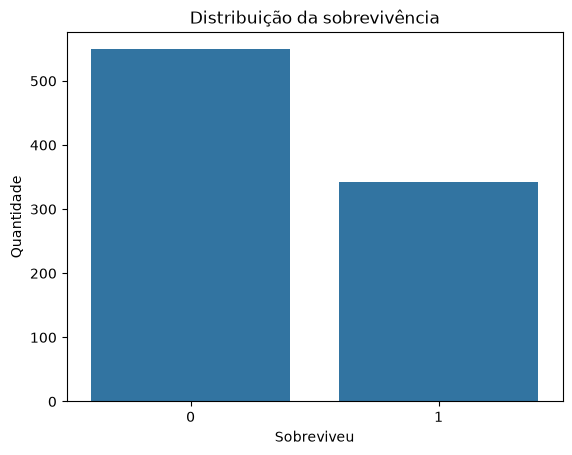

In [72]:
# Visualizar distribuição
sns.countplot(
    data=df,
    x="Survived",
)

plt.title("Distribuição da sobrevivência")
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")

plt.show()

In [73]:
# Missing values por coluna (Cabin tem 76% missing)
df.isna().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

## Modelo Tradicional: Logistic Regression

Abordagem supervisionada com feature engineering e pipeline.

In [74]:
# Feature engineering: criar indicador binário para cabin
df_model = df.copy()

df_model["HasCabin"] = (
    df_model["Cabin"]
    .notna()
    .astype(int)
)

In [75]:
# Definir features para treino e target
FEATURES = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked",
    "HasCabin",
]

TARGET = "Survived"

In [76]:
# Extrair X e y
X = df_model[FEATURES]
y = df_model[TARGET]

In [77]:
# Split 80/20 com estratificação
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

In [78]:
# Verificar tamanhos
print("Treinamento:", len(X_train))
print("Teste:", len(X_test))

Treinamento: 712
Teste: 179


In [79]:
# Pipeline de preprocessamento: features numéricas e categóricas
# Numéricas: imputar mediana + normalizar
# Categóricas: imputar moda + one-hot encoding

numeric_features = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
]

categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "HasCabin",
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent"),
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

In [80]:
# Construir pipeline: preprocessar → treinar LogisticRegression
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor,
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000
            ),
        ),
    ]
)

In [81]:
# Treinar modelo
logistic_model.fit(
    X_train,
    y_train,
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Pclass','Sex','Age',...,'Fare','Embarked','HasCabin']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all r

In [82]:
# Gerar predições e probabilidades no conjunto de teste
lr_pred = logistic_model.predict(
    X_test
)

lr_score = logistic_model.predict_proba(
    X_test
)[:, 1]  # P(survival=1)

## Usando Jev (Zero-shot)

Abordagem sem treinamento: Jev recebe estrutura semântica do passageiro.
Retorna probabilidade de sobrevivência baseada em análise semântica.

In [83]:
# Dicionários para conversão: valores numéricos → representação semântica
PASSENGER_CLASS = {
    1: "First class",
    2: "Second class",
    3: "Third class",
}

EMBARKATION_PORT = {
    "C": "Cherbourg",
    "Q": "Queenstown",
    "S": "Southampton",
}

In [84]:
def passenger_to_semantic_state(row):
    """
    Converter atributos numéricos do passageiro em representação semântica.
    Jev recebe esta estrutura, não valores brutos.
    """
    
    passenger_class = (
        PASSENGER_CLASS.get(row["Pclass"])
        if pd.notna(row["Pclass"])
        else None
    )

    embarkation_port = (
        EMBARKATION_PORT.get(row["Embarked"])
        if pd.notna(row["Embarked"])
        else None
    )

    age = (
        float(row["Age"])
        if pd.notna(row["Age"])
        else None
    )

    fare = (
        float(row["Fare"])
        if pd.notna(row["Fare"])
        else None
    )

    return {
        "passenger_class": passenger_class,

        "sex": (
            row["Sex"]
            if pd.notna(row["Sex"])
            else None
        ),

        "age_in_years": age,

        "number_of_siblings_or_spouses_aboard": (
            int(row["SibSp"])
        ),

        "number_of_parents_or_children_aboard": (
            int(row["Parch"])
        ),

        "passenger_fare": fare,

        "port_of_embarkation": embarkation_port,

        "has_recorded_cabin": bool(
            row["HasCabin"]
        ),
    }

In [85]:
# Exemplo: primeiro passageiro do conjunto de teste convertido
passenger_to_semantic_state(
    X_test.iloc[0]
)

{'passenger_class': 'Third class',
 'sex': 'male',
 'age_in_years': 24.0,
 'number_of_siblings_or_spouses_aboard': 2,
 'number_of_parents_or_children_aboard': 0,
 'passenger_fare': 24.15,
 'port_of_embarkation': 'Southampton',
 'has_recorded_cabin': False}

In [86]:
# Teste: chamar Jev para um passageiro individual
passenger = passenger_to_semantic_state(
    X_test.iloc[0]
)

with TypeSafeClient() as client:

    response = client.system_one(
        state={
            "passenger": passenger
        },
        questions={
            "survived": Noul(
                instructions=(
                    "Based only on the attributes of `passenger`, "
                    "is this passenger likely to have survived "
                    "the sinking of the Titanic?"
                ),
                criteria={
                    "true": (
                        "The passenger's attributes are consistent "
                        "with circumstances associated with survival."
                    ),
                    "false": (
                        "The passenger's attributes are consistent "
                        "with circumstances associated with not surviving."
                    ),
                },
            )
        },
    )

In [87]:
# Resultado: probabilidade de sobrevivência (Noul = 0-1)
response.answers["survived"]

NoulAnswer(type='noul', noul=0.19)

### Classificação em Lote com Jev

In [88]:
def predict_jev_dataset(
    df,
    batch_size=16,
):
    """
    Classificar dataset inteiro com Jev em batches.
    """

    probabilities = []

    with TypeSafeClient() as client:

        for start in tqdm(range(
            0,
            len(df),
            batch_size,
        )):

            end = min(
                start + batch_size,
                len(df),
            )

            batch = df.iloc[start:end]

            batch_probabilities = (
                predict_jev_batch(
                    client,
                    batch,
                )
            )

            probabilities.extend(
                batch_probabilities
            )

            print(
                f"{end}/{len(df)} passageiros classificados"
            )

    return np.array(
        probabilities
    )

In [89]:
def predict_jev_batch(
    client,
    batch,
):
    """
    Processar um batch de passageiros com uma única chamada à API Jev.
    """

    passengers = [
        passenger_to_semantic_state(row)
        for _, row in batch.iterrows()
    ]

    state = {
        "passengers": passengers
    }

    # Uma pergunta Noul por passageiro
    questions = {
        f"passenger_{i}": Noul(
            instructions=(
                f"Based only on the attributes of `passengers[{i}]`, "
                "is this passenger likely to have survived "
                "the sinking of the Titanic?"
            ),
            criteria={
                "true": (
                    "The passenger's characteristics are consistent "
                    "with circumstances associated with survival."
                ),
                "false": (
                    "The passenger's characteristics are consistent "
                    "with circumstances associated with not surviving."
                ),
            },
        )

        for i in range(len(passengers))
    }

    # Chamada única à API
    response = client.system_one(
        state=state,
        questions=questions,
    )

    return [
        response.answers[
            f"passenger_{i}"
        ].noul

        for i in range(len(passengers))
    ]

In [90]:
# Executar predições Jev sobre todos os passageiros de teste
jev_score = predict_jev_dataset(
    X_test,
    batch_size=16,
)

  8%|▊         | 1/12 [00:00<00:03,  3.02it/s]

16/179 passageiros classificados


 17%|█▋        | 2/12 [00:00<00:02,  3.40it/s]

32/179 passageiros classificados


 25%|██▌       | 3/12 [00:00<00:03,  2.98it/s]

48/179 passageiros classificados


 33%|███▎      | 4/12 [00:01<00:02,  3.21it/s]

64/179 passageiros classificados


 42%|████▏     | 5/12 [00:01<00:02,  3.27it/s]

80/179 passageiros classificados


 50%|█████     | 6/12 [00:01<00:01,  3.47it/s]

96/179 passageiros classificados


 58%|█████▊    | 7/12 [00:02<00:01,  3.62it/s]

112/179 passageiros classificados


 67%|██████▋   | 8/12 [00:02<00:01,  3.72it/s]

128/179 passageiros classificados


 75%|███████▌  | 9/12 [00:02<00:00,  3.79it/s]

144/179 passageiros classificados


 83%|███████▌ | 10/12 [00:02<00:00,  3.59it/s]

160/179 passageiros classificados


 92%|████████▎| 11/12 [00:03<00:00,  3.53it/s]

176/179 passageiros classificados


100%|█████████| 12/12 [00:03<00:00,  3.48it/s]

179/179 passageiros classificados


In [91]:
# Converter probabilidades em predições binárias
jev_pred = (
    jev_score >= THRESHOLD
).astype(int)

In [92]:
## Comparação de Resultados

# Compilar predições e probabilidades de ambos modelos
results = X_test.copy()

results["actual_survival"] = (
    y_test.to_numpy()
)

results["logistic_probability"] = (
    lr_score
)

results["logistic_prediction"] = (
    lr_pred
)

results["jev_probability"] = (
    jev_score
)

results["jev_prediction"] = (
    jev_pred
)

In [93]:
# Visualizar primeiros resultados
results.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,actual_survival,logistic_probability,logistic_prediction,jev_probability,jev_prediction
565,3,male,24.0,2,0,24.1500,S,0,0,0.066398,0,0.20,0
160,3,male,44.0,0,1,16.1000,S,0,0,0.045245,0,0.26,0
553,3,male,22.0,0,0,7.2250,C,0,1,0.157269,0,0.18,0
860,3,male,41.0,2,0,14.1083,S,0,0,0.035472,0,0.20,0
241,3,female,NaN,1,0,15.5000,Q,0,1,0.671555,1,0.28,0


In [94]:
def calculate_metrics(
    y_true,
    y_pred,
    y_score,
    model_name,
):
    """Calcular métricas de avaliação."""

    return {
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_true,
            y_pred,
        ),

        "Precision": precision_score(
            y_true,
            y_pred,
        ),

        "Recall": recall_score(
            y_true,
            y_pred,
        ),

        "F1": f1_score(
            y_true,
            y_pred,
        ),

        "ROC-AUC": roc_auc_score(
            y_true,
            y_score,
        ),

        "Average Precision": (
            average_precision_score(
                y_true,
                y_score,
            )
        ),
    }

In [95]:
# Compilar métricas: Logistic Regression vs Jev
metrics = pd.DataFrame([
    
    calculate_metrics(
        y_test,
        lr_pred,
        lr_score,
        "Logistic Regression",
    ),

    calculate_metrics(
        y_test,
        jev_pred,
        jev_score,
        "Jev",
    ),
])

# Logistic Regression vence em todas as métricas, mas Jev oferece explicabilidade
metrics

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision
0,Logistic Regression,0.810056,0.786885,0.695652,0.738462,0.838340,0.785777
1,Jev,0.715084,0.628571,0.637681,0.633094,0.746706,0.675247


In [96]:
# Relatório detalhado: Logistic Regression
print(
    classification_report(
        y_test,
        lr_pred,
        target_names=[
            "Did not survive",
            "Survived",
        ],
    )
)

                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



In [97]:

# Relatório detalhado: Jev
print(
    classification_report(
        y_test,
        jev_pred,
        target_names=[
            "Did not survive",
            "Survived",
        ],
    )
)

                 precision    recall  f1-score   support

Did not survive       0.77      0.76      0.77       110
       Survived       0.63      0.64      0.63        69

       accuracy                           0.72       179
      macro avg       0.70      0.70      0.70       179
   weighted avg       0.72      0.72      0.72       179



In [98]:
## Visualizações Comparativas

def plot_confusion_matrix(
    y_true,
    y_pred,
    title,
):
    """Plotar matriz de confusão."""

    cm = confusion_matrix(
        y_true,
        y_pred,
    )

    plt.figure(
        figsize=(6, 5)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cbar=False,
        xticklabels=[
            "Did not survive",
            "Survived",
        ],
        yticklabels=[
            "Did not survive",
            "Survived",
        ],
    )

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)

    plt.show()

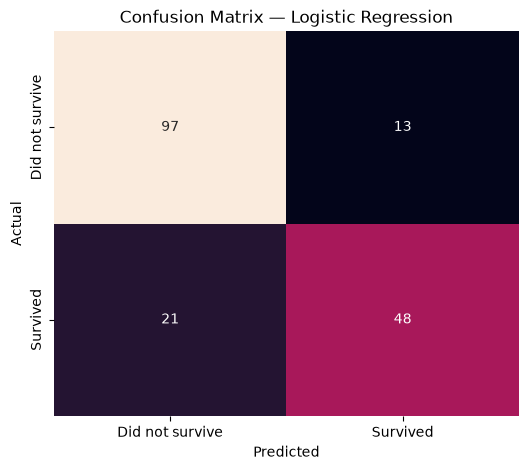

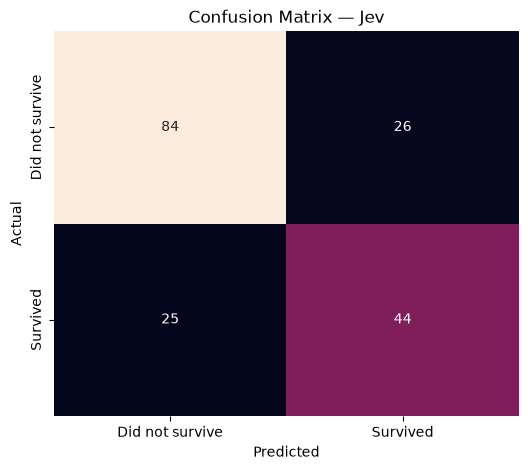

In [99]:
# Matrizes de confusão lado a lado
plot_confusion_matrix(
    y_test,
    lr_pred,
    "Confusion Matrix — Logistic Regression",
)

plot_confusion_matrix(
    y_test,
    jev_pred,
    "Confusion Matrix — Jev",
)

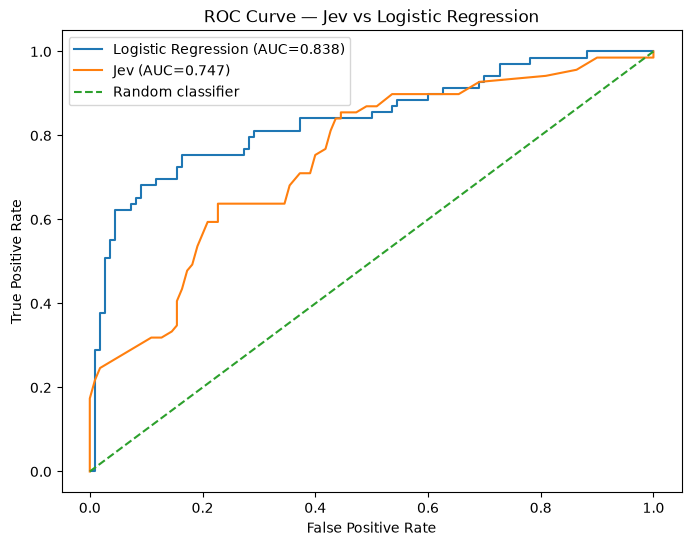

In [100]:
# Curvas ROC: comparação visual dos modelos
# Logistic Regression: AUC=0.838 vs Jev: AUC=0.747
lr_fpr, lr_tpr, _ = roc_curve(
    y_test,
    lr_score,
)

jev_fpr, jev_tpr, _ = roc_curve(
    y_test,
    jev_score,
)

lr_auc = roc_auc_score(
    y_test,
    lr_score,
)

jev_auc = roc_auc_score(
    y_test,
    jev_score,
)

plt.figure(
    figsize=(8, 6)
)

plt.plot(
    lr_fpr,
    lr_tpr,
    label=(
        f"Logistic Regression "
        f"(AUC={lr_auc:.3f})"
    ),
)

plt.plot(
    jev_fpr,
    jev_tpr,
    label=(
        f"Jev "
        f"(AUC={jev_auc:.3f})"
    ),
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier",
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "ROC Curve — Jev vs Logistic Regression"
)

plt.legend()

plt.show()

In [101]:
# Curva Precision-Recall para ambos modelos
lr_precision, lr_recall, _ = (
    precision_recall_curve(
        y_test,
        lr_score,
    )
)

jev_precision, jev_recall, _ = (
    precision_recall_curve(
        y_test,
        jev_score,
    )
)

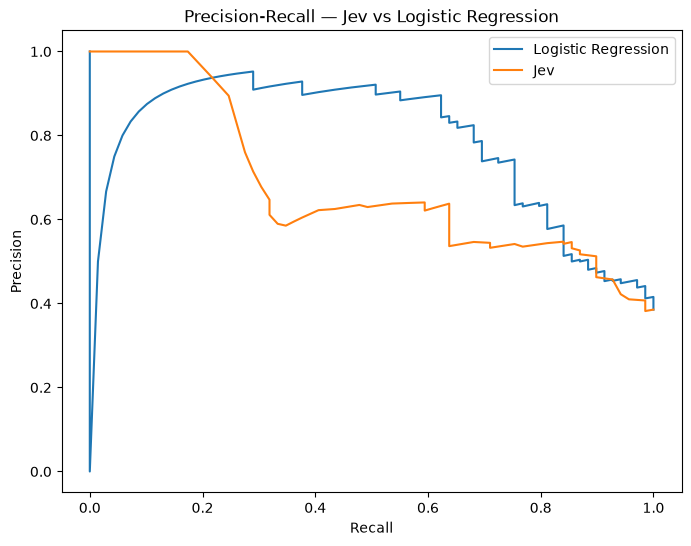

In [102]:
# Plotar Precision-Recall
plt.figure(
    figsize=(8, 6)
)

plt.plot(
    lr_recall,
    lr_precision,
    label="Logistic Regression",
)

plt.plot(
    jev_recall,
    jev_precision,
    label="Jev",
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall — Jev vs Logistic Regression"
)

plt.legend()

plt.show()

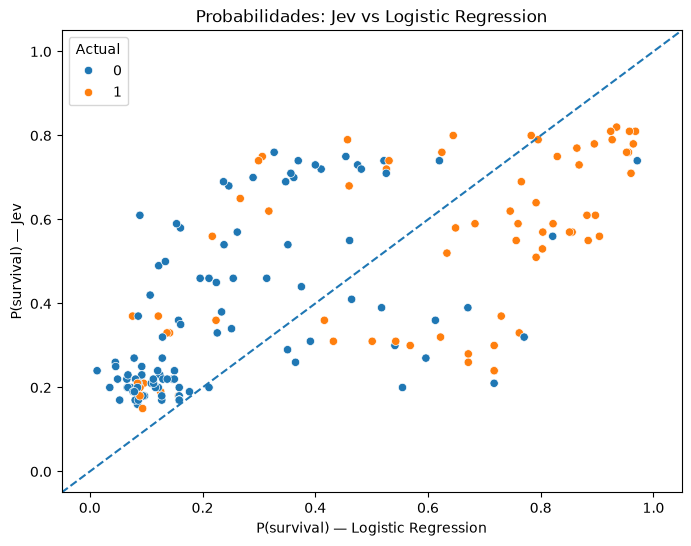

In [103]:
# Scatter: comparação direta de probabilidades
# Padrão interessante: Logistic Regression mais conservador (0-1 extremos)
# Jev mais intermediário (concentrado 0.3-0.7)
probability_comparison = pd.DataFrame({
    "Logistic Regression": lr_score,
    "Jev": jev_score,
    "Actual": y_test.to_numpy(),
})

plt.figure(
    figsize=(8, 6)
)

sns.scatterplot(
    data=probability_comparison,
    x="Logistic Regression",
    y="Jev",
    hue="Actual",
)

plt.axline(
    (0, 0),
    (1, 1),
    linestyle="--",
)

plt.xlabel(
    "P(survival) — Logistic Regression"
)

plt.ylabel(
    "P(survival) — Jev"
)

plt.title(
    "Probabilidades: Jev vs Logistic Regression"
)

plt.show()

In [104]:
# Encontrar casos de desacordo entre modelos
disagreements = results[
    results["logistic_prediction"]
    !=
    results["jev_prediction"]
].copy()

disagreements[
    [
        "Pclass",
        "Sex",
        "Age",
        "Fare",
        "actual_survival",
        "logistic_probability",
        "jev_probability",
        "logistic_prediction",
        "jev_prediction",
    ]
].sort_values(
    "jev_probability",
    ascending=False,
)

,Pclass,Sex,Age,Fare,actual_survival,logistic_probability,jev_probability,logistic_prediction,jev_prediction
690,1,male,31.00,57.0000,1,0.457305,0.79,0,1
92,1,male,46.00,61.1750,0,0.327085,0.76,0,1
712,1,male,48.00,52.0000,1,0.306095,0.75,0,1
671,1,male,31.00,52.0000,0,0.454287,0.75,0,1
587,1,male,60.00,79.2000,1,0.299423,0.74,0,1
536,1,male,45.00,26.5500,0,0.369832,0.74,0,1
245,1,male,44.00,90.0000,0,0.475168,0.73,0,1
137,1,male,37.00,53.1000,0,0.400152,0.73,0,1
336,1,male,29.00,66.6000,0,0.481727,0.72,0,1
698,1,male,49.00,110.8833,0,0.410470,0.72,0,1


## Explicabilidade Estruturada

Usar Jev para decompor decisões em fatores interpretáveis:
- Demographic advantage (sexo, idade)
- Class advantage (classe do passageiro)
- Family advantage (configuração familiar)
- Economic advantage (tarifa, cabin)

In [105]:
def explain_jev_batch(
    client,
    batch,
):
    """
    Chamar Jev com 5 perguntas estruturadas por passageiro.
    Retorna probabilidades para cada fator explicativo.
    """

    passengers = [
        passenger_to_semantic_state(row)
        for _, row in batch.iterrows()
    ]

    state = {
        "passengers": passengers
    }

    questions = {}

    # Para cada passageiro, 5 perguntas sobre fatores diferentes
    for i in range(
        len(passengers)
    ):

        questions[
            f"survival_{i}"
        ] = Noul(
            instructions=(
                f"Based only on `passengers[{i}]`, "
                "are this passenger's characteristics "
                "generally favorable to survival in "
                "the Titanic disaster?"
            )
        )

        questions[
            f"demographic_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on the sex and age of "
                f"`passengers[{i}]`, are the passenger's "
                "demographic characteristics favorable "
                "to survival?"
            )
        )

        questions[
            f"class_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on the passenger class of "
                f"`passengers[{i}]`, is the passenger's "
                "travel class favorable to survival?"
            )
        )

        questions[
            f"family_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on the numbers of siblings, spouses, "
                f"parents and children in `passengers[{i}]`, "
                "does the family situation appear favorable "
                "to survival?"
            )
        )

        questions[
            f"economic_advantage_{i}"
        ] = Noul(
            instructions=(
                f"Based on fare, passenger class and whether "
                f"`passengers[{i}]` has a recorded cabin, "
                "do these attributes suggest circumstances "
                "favorable to survival?"
            )
        )

    response = client.system_one(
        state=state,
        questions=questions,
    )

    rows = []

    # Extrair respostas
    for i in range(
        len(passengers)
    ):

        rows.append({
            "survival_factor": (
                response.answers[
                    f"survival_{i}"
                ].noul
            ),

            "demographic_advantage": (
                response.answers[
                    f"demographic_advantage_{i}"
                ].noul
            ),

            "class_advantage": (
                response.answers[
                    f"class_advantage_{i}"
                ].noul
            ),

            "family_advantage": (
                response.answers[
                    f"family_advantage_{i}"
                ].noul
            ),

            "economic_advantage": (
                response.answers[
                    f"economic_advantage_{i}"
                ].noul
            ),
        })

    return rows

In [106]:
# Extrair índices de erros (previsões incorretas do Jev)
error_indices = results[
    results["actual_survival"]
    !=
    results["jev_prediction"]
].index

X_errors = X_test.loc[
    error_indices
]

In [107]:
# Chamar explicação estruturada para passageiros com previsões erradas
explanations = []

BATCH_SIZE = 8

with TypeSafeClient() as client:

    for start in range(
        0,
        len(X_errors),
        BATCH_SIZE,
    ):

        batch = X_errors.iloc[
            start:start + BATCH_SIZE
        ]

        explanations.extend(
            explain_jev_batch(
                client,
                batch,
            )
        )

explanation_df = (
    X_errors.copy()
    .reset_index(drop=True)
)      

explanation_values = pd.DataFrame(
    explanations
)

explanation_df = pd.concat(
    [
        explanation_df,
        explanation_values,
    ],
    axis=1,
)

explanation_df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,HasCabin,survival_factor,demographic_advantage,class_advantage,family_advantage,economic_advantage
0,3,male,22.00,0,0,7.2250,C,0,0.41,0.60,0.10,0.30,0.17
1,3,female,NaN,1,0,15.5000,Q,0,0.31,0.70,0.11,0.46,0.25
2,3,female,36.00,1,0,17.4000,S,0,0.32,0.68,0.13,0.44,0.23
3,1,male,45.00,0,0,26.5500,S,1,0.78,0.78,0.88,0.34,0.81
4,1,male,49.00,1,1,110.8833,C,1,0.83,0.67,0.88,0.56,0.86
5,2,male,34.00,1,0,26.0000,S,0,0.56,0.66,0.59,0.44,0.41
6,3,female,27.00,0,0,7.9250,S,0,0.31,0.74,0.13,0.31,0.20
7,2,male,31.00,1,1,37.0042,C,0,0.58,0.40,0.46,0.54,0.45
8,1,male,19.00,3,2,263.0000,S,1,0.82,0.73,0.88,0.52,0.83
9,3,female,35.00,1,1,20.2500,S,0,0.31,0.74,0.12,0.54,0.27


In [108]:
# Adicionar labels reais e predições do Jev
error_results = results.loc[
    error_indices
].reset_index(drop=True)

explanation_df["actual_survival"] = (
    error_results["actual_survival"]
)

explanation_df["jev_probability"] = (
    error_results["jev_probability"]
)

explanation_df["jev_prediction"] = (
    error_results["jev_prediction"]
)

# Visualizar explicações
explanation_df[
    [
        "Sex",
        "Age",
        "Pclass",
        "Fare",
        "actual_survival",
        "jev_probability",
        "demographic_advantage",
        "class_advantage",
        "family_advantage",
        "economic_advantage",
    ]
]

,Sex,Age,Pclass,Fare,actual_survival,jev_probability,demographic_advantage,class_advantage,family_advantage,economic_advantage
0,male,22.00,3,7.2250,1,0.18,0.60,0.10,0.30,0.17
1,female,NaN,3,15.5000,1,0.28,0.70,0.11,0.46,0.25
2,female,36.00,3,17.4000,1,0.31,0.68,0.13,0.44,0.23
3,male,45.00,1,26.5500,0,0.74,0.78,0.88,0.34,0.81
4,male,49.00,1,110.8833,0,0.72,0.67,0.88,0.56,0.86
5,male,34.00,2,26.0000,0,0.58,0.66,0.59,0.44,0.41
6,female,27.00,3,7.9250,1,0.30,0.74,0.13,0.31,0.20
7,male,31.00,2,37.0042,0,0.54,0.40,0.46,0.54,0.45
8,male,19.00,1,263.0000,0,0.74,0.73,0.88,0.52,0.83
9,female,35.00,3,20.2500,1,0.36,0.74,0.12,0.54,0.27


In [109]:
def build_explanation(row):
    """
    Construir explicação textual a partir dos fatores probabilísticos.
    Threshold: 0.7 = favorable, 0.3 = unfavorable.
    """

    positive = []
    negative = []

    if row["demographic_advantage"] >= 0.7:
        positive.append(
            "demographic characteristics"
        )

    elif row["demographic_advantage"] <= 0.3:
        negative.append(
            "demographic characteristics"
        )

    if row["class_advantage"] >= 0.7:
        positive.append(
            "passenger class"
        )

    elif row["class_advantage"] <= 0.3:
        negative.append(
            "passenger class"
        )

    if row["family_advantage"] >= 0.7:
        positive.append(
            "family configuration"
        )

    elif row["family_advantage"] <= 0.3:
        negative.append(
            "family configuration"
        )

    if row["economic_advantage"] >= 0.7:
        positive.append(
            "fare/cabin circumstances"
        )

    elif row["economic_advantage"] <= 0.3:
        negative.append(
            "fare/cabin circumstances"
        )

    explanation = []

    if positive:
        explanation.append(
            "Favorable: "
            + ", ".join(positive)
        )

    if negative:
        explanation.append(
            "Unfavorable: "
            + ", ".join(negative)
        )

    return " | ".join(
        explanation
    )

In [110]:
# Gerar explicações textuais
explanation_df["explanation"] = (
    explanation_df.apply(
        build_explanation,
        axis=1,
    )
)

# Visualizar explicações ao lado das predições
explanation_df[
    [
        "actual_survival",
        "jev_probability",
        "explanation",
    ]
]

,actual_survival,jev_probability,explanation
0,1,0.18,"Unfavorable: passenger class, family configura..."
1,1,0.28,Favorable: demographic characteristics | Unfav...
2,1,0.31,"Unfavorable: passenger class, fare/cabin circu..."
3,0,0.74,"Favorable: demographic characteristics, passen..."
4,0,0.72,"Favorable: passenger class, fare/cabin circums..."
5,0,0.58,
6,1,0.30,Favorable: demographic characteristics | Unfav...
7,0,0.54,
8,0,0.74,"Favorable: demographic characteristics, passen..."
9,1,0.36,Favorable: demographic characteristics | Unfav...


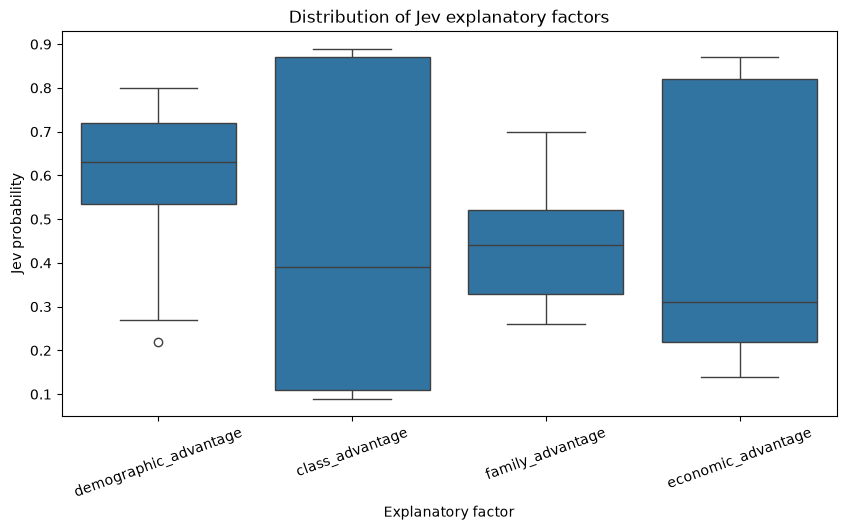

In [111]:
# Distribuição dos fatores explicativos
explanation_long = (
    explanation_df[
        [
            "demographic_advantage",
            "class_advantage",
            "family_advantage",
            "economic_advantage",
        ]
    ]
    .melt(
        var_name="factor",
        value_name="probability",
    )
)

plt.figure(
    figsize=(10, 5)
)

sns.boxplot(
    data=explanation_long,
    x="factor",
    y="probability",
)

plt.xticks(
    rotation=20
)

plt.xlabel(
    "Explanatory factor"
)

plt.ylabel(
    "Jev probability"
)

plt.title(
    "Distribution of Jev explanatory factors"
)

plt.show()

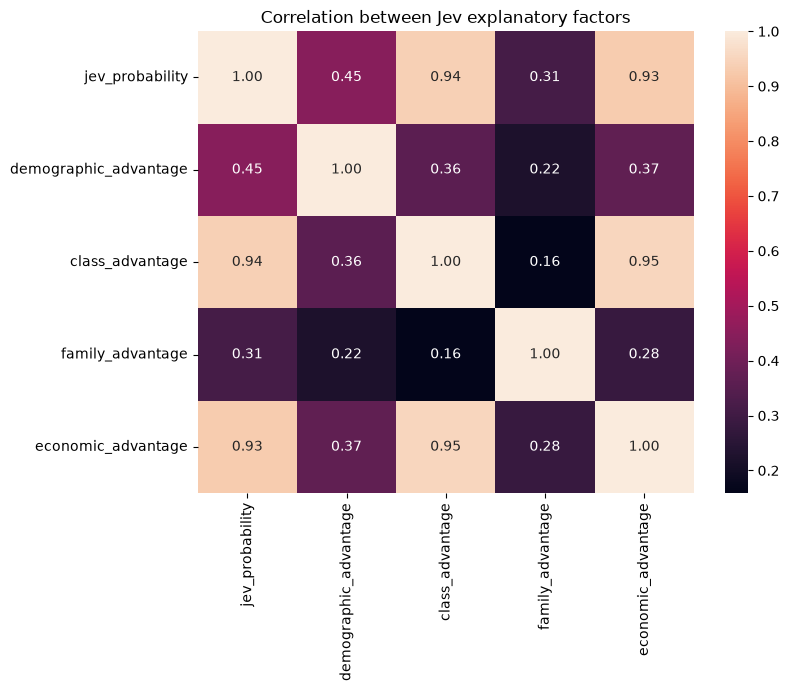

In [112]:
# Matriz de correlação: como os fatores se relacionam
correlation_columns = [
    "jev_probability",
    "demographic_advantage",
    "class_advantage",
    "family_advantage",
    "economic_advantage",
]

correlation = (
    explanation_df[
        correlation_columns
    ]
    .corr()
)

plt.figure(
    figsize=(8, 6)
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
)

plt.title(
    "Correlation between Jev explanatory factors"
)

plt.show()